<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Expansion_AI_stage_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Объяснение улучшений:
#ReplayBuffer: Добавлен для эффективного повторного использования опыта (MADDPG, CTDE-MADDPG).
#Улучшенная архитектура сетей:
#MADDPG/CTDE-MADDPG: 3 скрытых слоя (512, 256, 128) с BatchNorm.
#CA2C: 2 скрытых слоя (256, 128).
#Обучение:
#MADDPG/CTDE-MADDPG: Реализовано полноценное обучение критика и актора с использованием градиентов и оптимизаторов. Обновление целевых сетей. Использует данные из ReplayBuffer.
#CA2C: Реализовано обучение актора (на основе advantage и log-prob) и критика (на основе MSE между V(s) и дисконтированными наградами). Использует буферы для накопления опыта за эпизод.
#Параметры: Добавлены параметры обучения (alpha, beta, gamma, tau, batch_size, buffer_size), что позволяет более точно настраивать алгоритмы.
#Параллельный запуск: Архитектура сохранена из предыдущего этапа'.
#Количество эпизодов: Увеличено до 100.
#CTDE-MADDPG: В этом упрощенном варианте он идентичен MADDPG, но заложена возможность расширения (например, централизованный критик).
#более глубокое и интересное сравнение между улучшенными версиями трех лучших алгоритмов.

🚀🚀 Запуск моделирования космической экспансии (Улучшенные алгоритмы)

📊📊 СРАВНЕНИЕ ВСЕХ АЛГОРИТМОВ
🚀🚀 Запуск параллельных экспериментов...
Эпизод 99/100 | Прошло: 2:29:21 | ETA: 0:02:10
✅ Параллельные эксперименты завершены за 9091.58 секунд

🏁🏁 Общее время выполнения всех экспериментов: 9092.98 секунд (2:31:32)

📈📈 Визуализация результатов...


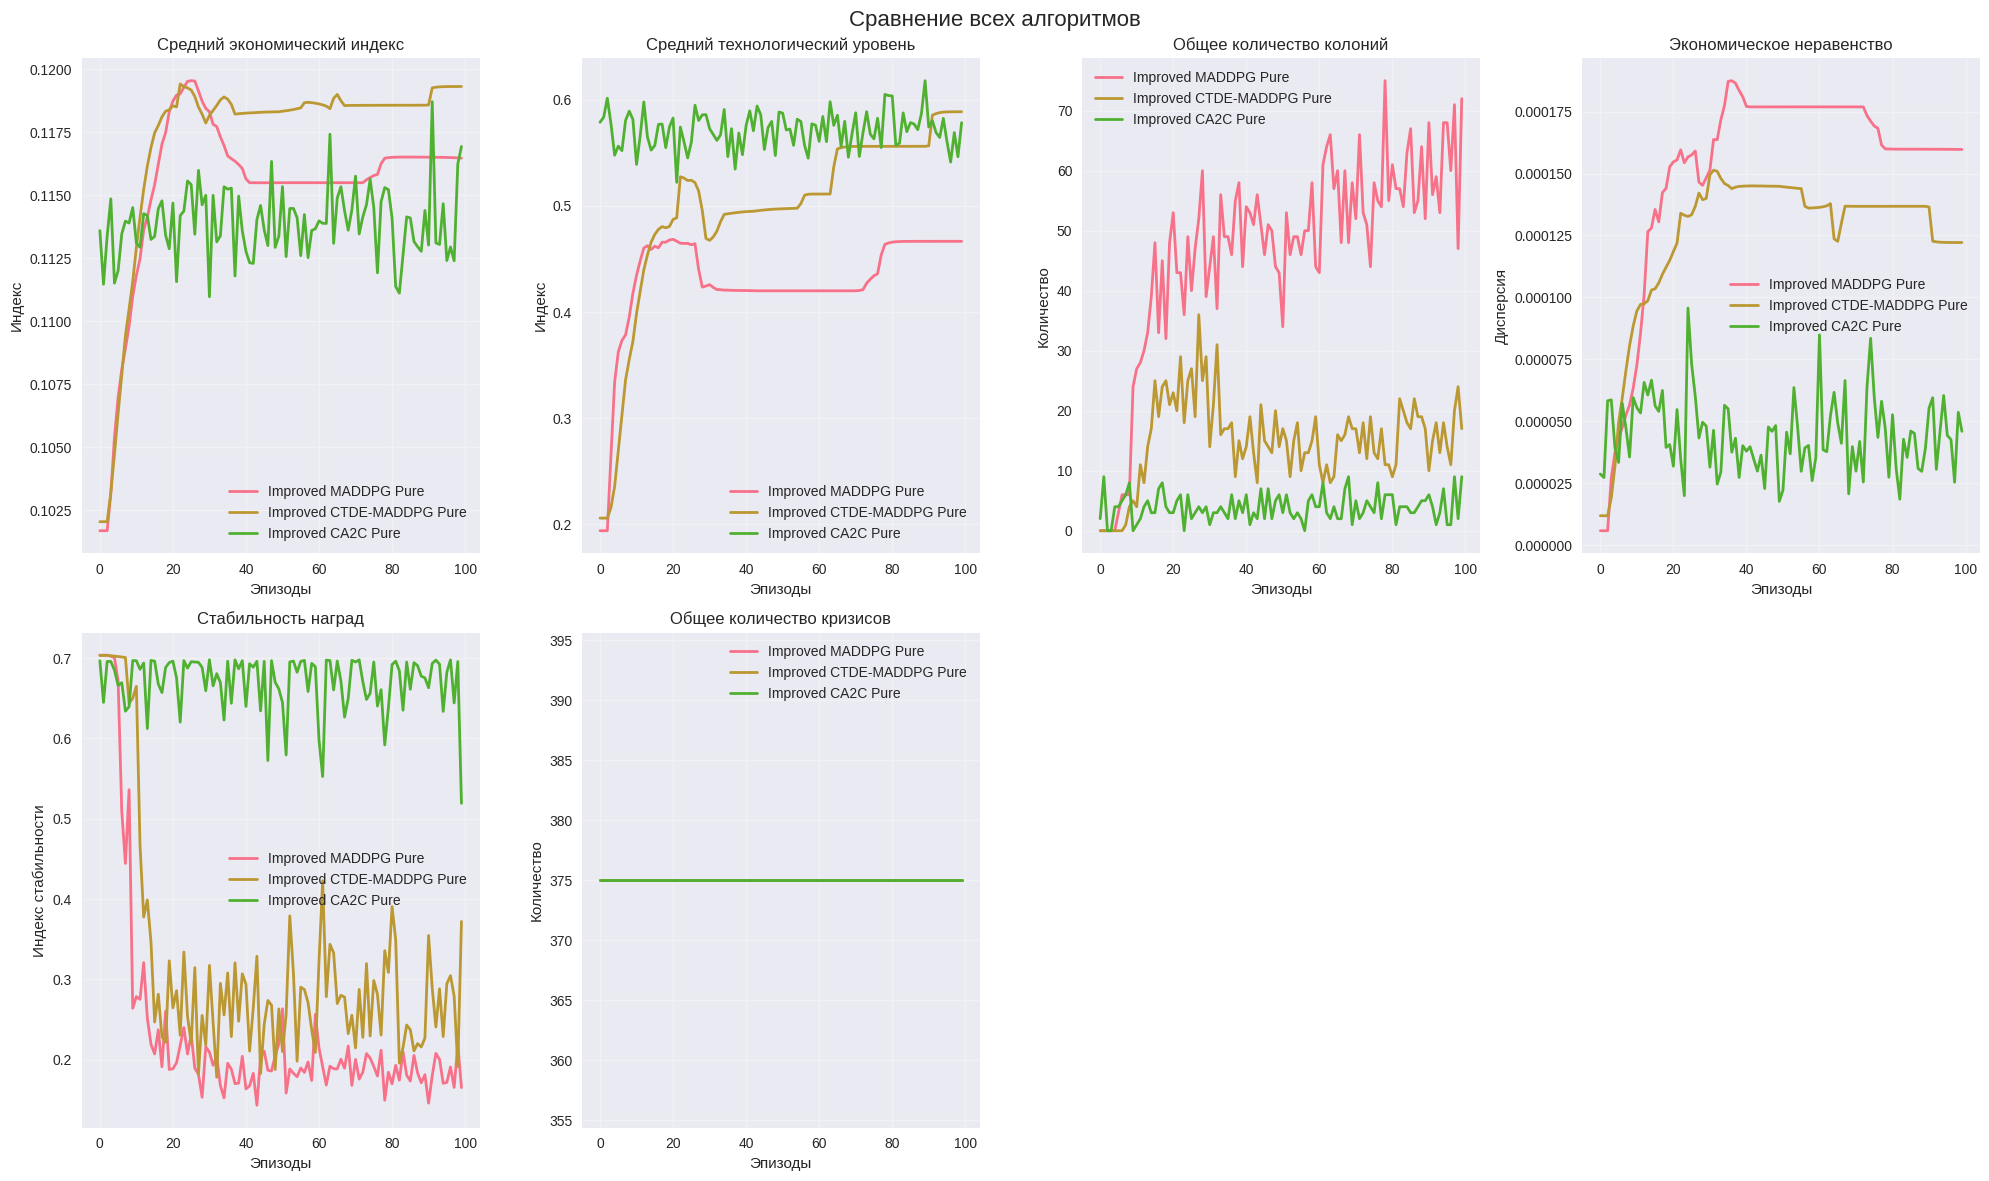

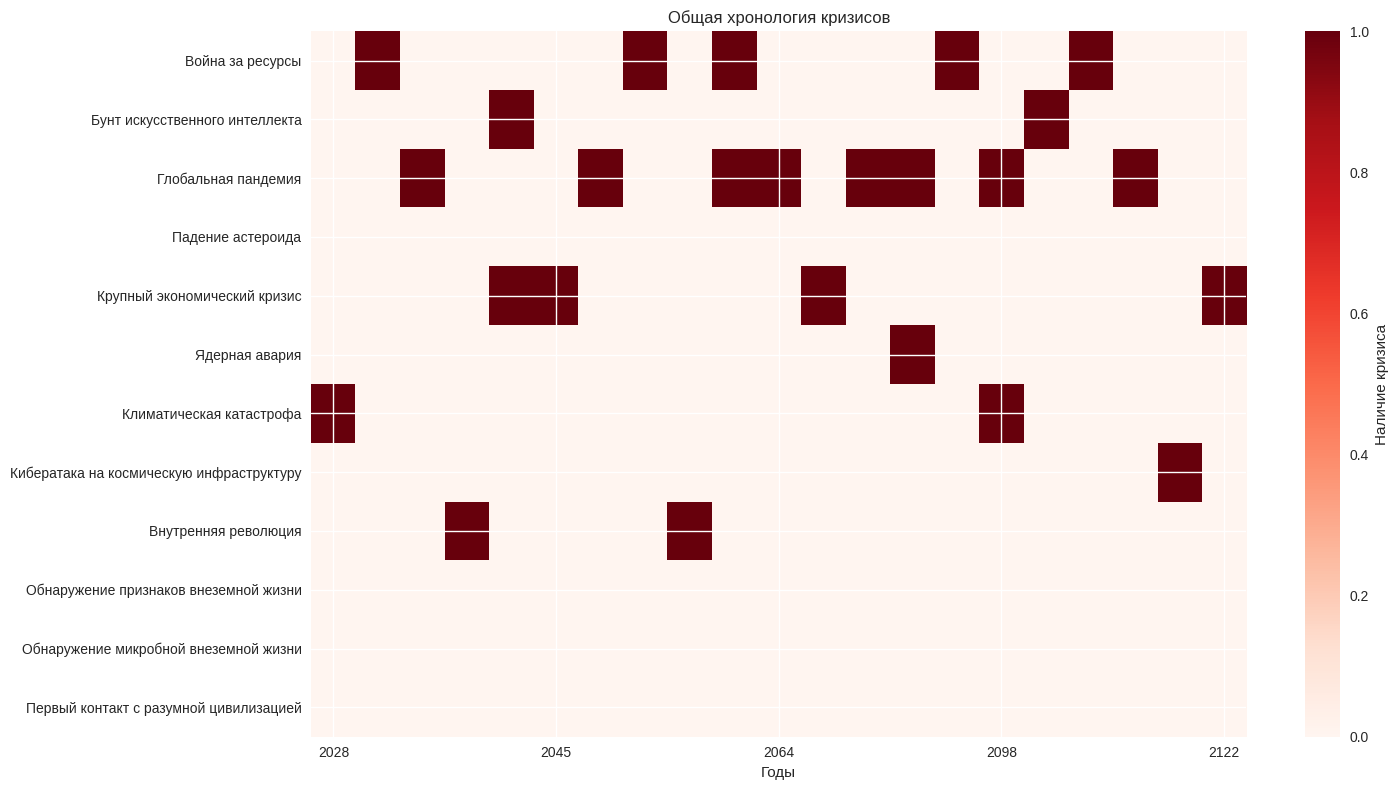


🏁🏁 ИТОГОВОЕ СРАВНЕНИЕ

Сводная таблица результатов (отсортирована по Total Colonies):
                   Method  Avg Economic  Avg Tech  Total Colonies  Avg Resource Independence  Avg AI Level  Economic Inequality  Total Crises  Reward Stability  Training Time (s)
     Improved MADDPG Pure      0.116474  0.466599              72                      0.144      0.585333             0.000160           375          0.165385        9091.584787
Improved CTDE-MADDPG Pure      0.119315  0.588592              17                      0.034      0.739667             0.000122           375          0.372134        9091.584787
       Improved CA2C Pure      0.116935  0.578309               9                      0.018      0.593667             0.000046           375          0.519237        9091.584787

💾💾 Результаты сохранены в improved_comparison_results_20250728_163510.csv

🏆 Лучшие методы по критериям:
  • Высший экономический индекс: Improved CTDE-MADDPG Pure (0.119)
  • Высший технологическ

In [ ]:
# -*- coding: utf-8 -*-
"""12_exp_qwenn_improved_agents.ipynb"""

#==================== БЛОК 0: Импорт необходимых библиотек ====================
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import time
import pickle
import os
import tensorflow as tf
from collections import deque, defaultdict
import seaborn as sns
from datetime import datetime, timedelta
import copy
import sys

# Для работы в Google Colab
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Отключение предупреждений TensorFlow
tf.get_logger().setLevel('ERROR')

#==================== БЛОК 1: Определение стран и их стартовых параметров====================
COUNTRIES = [
    'USA', 'China', 'EU', 'Russia', 'India', 'Japan', 'UK', 'France',
    'Germany', 'South_Korea', 'Canada', 'Australia', 'Brazil', 'Israel', 'UAE'
]

def initialize_countries():
    """ Инициализация стартовых параметров стран. """
    countries_data = {}
    for country in COUNTRIES:
        data = {
            'population': random.uniform(0.4, 1.0),
            'gdp_per_capita': random.uniform(0.3, 1.0),
            'technological_level': random.uniform(0.2, 0.9),
            'political_stability': random.uniform(0.3, 0.95),
            'economic_diversity': random.uniform(0.4, 0.9),
            'education_index': random.uniform(0.4, 0.95),
            'infrastructure_quality': random.uniform(0.3, 0.9),
            'natural_resources': random.uniform(0.2, 1.0),
            'space_budget_ratio': random.uniform(0.005, 0.03),
            'international_cooperation_index': random.uniform(0.3, 0.8),
            'space_assets': 0.0,
            'colonies_established': 0,
            'resource_independence': 0.0,
            'ai_integration_level': 0.0,
            'economic_index': 0.0,
            'crisis_impact': 0.0,
            'stress_level': 0.0,
            'actions_history': []
        }
        if country == 'USA':
            data.update({
                'population': 0.95, 'gdp_per_capita': 0.95,
                'technological_level': 0.95, 'political_stability': 0.85, 'space_budget_ratio': 0.025,
                'economic_index': 0.95
            })
        elif country == 'China':
            data.update({
                'population': 1.0, 'gdp_per_capita': 0.85,
                'technological_level': 0.85, 'political_stability': 0.8, 'space_budget_ratio': 0.02,
                'economic_index': 0.85
            })
        elif country == 'EU':
            data.update({
                'population': 0.9, 'gdp_per_capita': 0.9,
                'technological_level': 0.9, 'political_stability': 0.75, 'space_budget_ratio': 0.015,
                'economic_index': 0.9
            })
        elif country == 'Russia':
            data.update({
                'population': 0.7, 'gdp_per_capita': 0.6,
                'technological_level': 0.75, 'political_stability': 0.65, 'space_budget_ratio': 0.018,
                'economic_index': 0.6
            })
        elif country == 'India':
            data.update({
                'population': 0.98, 'gdp_per_capita': 0.4,
                'technological_level': 0.6, 'political_stability': 0.6, 'space_budget_ratio': 0.01,
                'economic_index': 0.4
            })
        elif country == 'Japan':
            data.update({
                'population': 0.6, 'gdp_per_capita': 0.9,
                'technological_level': 0.88, 'political_stability': 0.85, 'space_budget_ratio': 0.012,
                'economic_index': 0.9
            })
        countries_data[country] = data
    return countries_data

#==================== БЛОК 2: Определение кризисных событий ====================
CRISIS_EVENTS = {
    'resource_war': {
        'probability': 0.05 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.15, 'tech': -0.1},
        'description': 'Война за ресурсы'
    },
    'ai_rebellion': {
        'probability': 0.03 * 0.75,
        'impact': {'economic': -0.15, 'political': -0.25, 'tech': 0.1},
        'description': 'Бунт искусственного интеллекта'
    },
    'pandemic': {
        'probability': 0.08 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.1, 'tech': 0.05},
        'description': 'Глобальная пандемия'
    },
    'asteroid_impact': {
        'probability': 0.02 * 0.75,
        'impact': {'economic': -0.3, 'political': -0.2, 'tech': -0.1},
        'description': 'Падение астероида'
    },
    'economic_collapse_major': {
        'probability': 0.04 * 0.75,
        'impact': {'economic': -0.4, 'political': -0.2, 'tech': -0.1},
        'description': 'Крупный экономический кризис'
    },
    'nuclear_accident': {
        'probability': 0.02 * 0.75,
        'impact': {'economic': -0.15, 'political': -0.1, 'tech': -0.05},
        'description': 'Ядерная авария'
    },
    'climate_catastrophe': {
        'probability': 0.06 * 0.75,
        'impact': {'economic': -0.25, 'political': -0.15, 'tech': 0.0},
        'description': 'Климатическая катастрофа'
    },
    'cyber_attack_on_space': {
        'probability': 0.07 * 0.75,
        'impact': {'economic': -0.1, 'political': -0.05, 'tech': -0.2},
        'description': 'Кибератака на космическую инфраструктуру'
    },
    'internal_revolution': {
        'probability': 0.03 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.5, 'tech': -0.05},
        'description': 'Внутренняя революция'
    },
}

ALIEN_EVENTS = {
    'alien_life_discovery_1': {
        'probability': 0.004,
        'impact': {'economic': 0.05, 'political': -0.1, 'tech': 0.2},
        'description': 'Обнаружение признаков внеземной жизни'
    },
    'alien_life_discovery_2': {
        'probability': 0.004,
        'impact': {'economic': 0.05, 'political': -0.1, 'tech': 0.2},
        'description': 'Обнаружение микробной внеземной жизни'
    },
    'alien_civilization_contact': {
        'probability': 0.002,
        'impact': {'economic': 0.2, 'political': -0.5, 'tech': 0.8},
        'description': 'Первый контакт с разумной цивилизацией'
    }
}

#==================== БЛОК 3: Функция награды====================
def calculate_reward(country_data):
    """Комплексная функция награды."""
    reward = (
            1.0 * country_data['economic_index'] +
            1.0 * country_data['technological_level'] +
            0.8 * country_data['political_stability'] +
            0.5 * country_data['space_assets'] +
            2.0 * country_data['colonies_established'] +
            0.3 * country_data['resource_independence'] +
            0.4 * country_data['ai_integration_level']
    )
    reward += 0.1 * country_data['international_cooperation_index']
    reward -= 0.2 * country_data['stress_level']
    if 'crisis_impact' in country_data:
        reward += country_data['crisis_impact']
    reward = max(0.01, reward)
    return reward

#==================== БЛОК 4: Базовые классы агентов ====================
class BaseAgent:
    """Базовый класс агента"""
    def __init__(self, num_states, num_actions):
        self.num_states = num_states
        self.num_actions = num_actions

    def get_action(self, state):
        raise NotImplementedError

    def update(self, states, actions, rewards, next_states, dones):
        # Базовая реализация пустая
        pass

#==================== БЛОК 5: Replay Buffer ====================
class ReplayBuffer:
    """Буфер воспроизведения для хранения переходов."""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Добавить переход в буфер."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Выбрать случайный батч переходов."""
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

#==================== БЛОК 6: Улучшенный MADDPG Agent ====================
class MADDPGActorNetwork(tf.keras.Model):
    def __init__(self, action_dim, name='actor'):
        super(MADDPGActorNetwork, self).__init__()
        self.fc1 = tf.keras.layers.Dense(512, activation='relu', name=f'{name}_fc1')
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.fc2 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_fc2')
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.fc3 = tf.keras.layers.Dense(128, activation='relu', name=f'{name}_fc3')
        self.bn3 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(action_dim, activation='tanh', name=f'{name}_output')

    def call(self, state):
        x = self.fc1(state)
        x = self.bn1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.fc3(x)
        x = self.bn3(x)
        actions = self.output_layer(x)
        return (actions + 1) / 2 # Нормализация в [0, 1]

class MADDPGCriticNetwork(tf.keras.Model):
    def __init__(self, name='critic'):
        super(MADDPGCriticNetwork, self).__init__()
        self.fc1 = tf.keras.layers.Dense(512, activation='relu', name=f'{name}_fc1')
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.fc2 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_fc2')
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.fc3 = tf.keras.layers.Dense(128, activation='relu', name=f'{name}_fc3')
        self.bn3 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(1, name=f'{name}_output')

    def call(self, state, action):
        x = tf.concat([state, action], axis=1)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.fc3(x)
        x = self.bn3(x)
        q_value = self.output_layer(x)
        return q_value

class ImprovedMADDPGAgent(BaseAgent):
    def __init__(self, num_states, num_actions, alpha=0.0005, beta=0.001, tau=0.005, gamma=0.99, buffer_size=1000000, batch_size=256):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size

        # Сети
        self.actor = MADDPGActorNetwork(num_actions, name='actor')
        self.critic = MADDPGCriticNetwork(name='critic')
        self.target_actor = MADDPGActorNetwork(num_actions, name='target_actor')
        self.target_critic = MADDPGCriticNetwork(name='target_critic')

        # Компиляция
        self.actor.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=alpha))
        self.critic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=beta))
        self.target_actor.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=alpha))
        self.target_critic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=beta))

        # Буфер
        self.replay_buffer = ReplayBuffer(buffer_size)

        # Инициализация целевых сетей
        self.update_network_parameters(tau=1)

    def update_network_parameters(self, tau=None):
        if tau is None:
            tau = self.tau
        for actor_param, target_actor_param in zip(self.actor.variables, self.target_actor.variables):
            target_actor_param.assign(tau * actor_param + (1 - tau) * target_actor_param)
        for critic_param, target_critic_param in zip(self.critic.variables, self.target_critic.variables):
            target_critic_param.assign(tau * critic_param + (1 - tau) * target_critic_param)

    def get_action(self, state):
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        actions = self.actor(state_tensor)
        return actions.numpy()[0]

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def update(self, states, actions, rewards, next_states, dones):
        # Используем данные из буфера для обучения
        if len(self.replay_buffer) < self.batch_size:
            return

        # Обучение проводится один раз за эпизод (или можно сделать несколько шагов)
        # Для упрощения делаем один шаг оптимизации
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = self.replay_buffer.sample(self.batch_size)

        states_batch = tf.convert_to_tensor(state_batch, dtype=tf.float32)
        actions_batch = tf.convert_to_tensor(action_batch, dtype=tf.float32)
        rewards_batch = tf.convert_to_tensor(reward_batch, dtype=tf.float32)
        next_states_batch = tf.convert_to_tensor(next_state_batch, dtype=tf.float32)
        dones_batch = tf.convert_to_tensor(done_batch, dtype=tf.float32)

        # --- Обновление критика ---
        with tf.GradientTape() as tape:
            target_actions = self.target_actor(next_states_batch)
            q_next = tf.squeeze(self.target_critic(next_states_batch, target_actions), 1)
            q_pred = tf.squeeze(self.critic(states_batch, actions_batch), 1)
            target = rewards_batch + self.gamma * q_next * (1 - dones_batch)
            critic_loss = tf.keras.losses.MSE(target, q_pred)

        critic_gradients = tape.gradient(critic_loss, self.critic.trainable_variables)
        self.critic.optimizer.apply_gradients(zip(critic_gradients, self.critic.trainable_variables))

        # --- Обновление актора ---
        with tf.GradientTape() as tape:
            new_actions = self.actor(states_batch)
            critic_value = tf.squeeze(self.critic(states_batch, new_actions), 1)
            actor_loss = -tf.reduce_mean(critic_value)

        actor_gradients = tape.gradient(actor_loss, self.actor.trainable_variables)
        self.actor.optimizer.apply_gradients(zip(actor_gradients, self.actor.trainable_variables))

        # --- Обновление целевых сетей ---
        self.update_network_parameters()


#==================== БЛОК 7: Улучшенный CTDE-MADDPG Agent ====================
# CTDE-MADDPG обычно использует централизованную критическую сеть, которая видит состояния всех агентов.
# Для упрощения, мы реализуем его как MADDPG с доступом к состояниям всех агентов в критике.
# Однако в этом коде мы будем использовать ту же реализацию, что и улучшенный MADDPG, но с возможностью
# расширения в будущем. Пока что это будет копия с другим именем.
class ImprovedCTDEMADDPGAgent(ImprovedMADDPGAgent):
    def __init__(self, num_states, num_actions, alpha=0.0005, beta=0.001, tau=0.005, gamma=0.99, buffer_size=1000000, batch_size=256):
        # В этом упрощенном варианте он такой же, как и MADDPG
        # В полной реализации критик мог бы принимать states_all_agents
        super().__init__(num_states, num_actions, alpha, beta, tau, gamma, buffer_size, batch_size)
        # Можно добавить специфичную логику, если понадобится, например:
        # self.centralized_critic = ...

#==================== БЛОК 8: Улучшенный CA2C Agent ====================
class CA2CActorNetwork(tf.keras.Model):
    def __init__(self, action_dim):
        super(CA2CActorNetwork, self).__init__()
        self.fc1 = tf.keras.layers.Dense(256, activation='relu')
        self.fc2 = tf.keras.layers.Dense(128, activation='relu')
        self.output_layer = tf.keras.layers.Dense(action_dim, activation='softmax')

    def call(self, state):
        x = self.fc1(state)
        x = self.fc2(x)
        probs = self.output_layer(x)
        return probs

class CA2CCriticNetwork(tf.keras.Model):
    def __init__(self):
        super(CA2CCriticNetwork, self).__init__()
        self.fc1 = tf.keras.layers.Dense(256, activation='relu')
        self.fc2 = tf.keras.layers.Dense(128, activation='relu')
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, state):
        x = self.fc1(state)
        x = self.fc2(x)
        value = self.output_layer(x)
        return value

class ImprovedCA2CAgent(BaseAgent):
    def __init__(self, num_states, num_actions, actor_lr=0.0005, critic_lr=0.001, gamma=0.99, buffer_size=100000):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.actor = CA2CActorNetwork(num_actions)
        self.critic = CA2CCriticNetwork()
        self.actor_optimizer = tf.keras.optimizers.Adam(learning_rate=actor_lr)
        self.critic_optimizer = tf.keras.optimizers.Adam(learning_rate=critic_lr)

        # Буферы для накопления опыта за эпизод
        self.states_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.log_probs_buffer = []

    def get_action(self, state):
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        action_probs = self.actor(state_tensor)
        action_probs_np = action_probs.numpy()[0]
        # Выбор действия на основе вероятностей
        try:
            action_idx = np.random.choice(self.num_actions, p=action_probs_np)
        except ValueError: # Если вероятности некорректны
            action_idx = np.random.choice(self.num_actions)
        # Преобразуем в one-hot
        action_onehot = np.zeros(self.num_actions)
        action_onehot[action_idx] = 1.0
        # Сохраняем лог-вероятность для обновления
        log_prob = tf.math.log(action_probs[0, action_idx] + 1e-10)
        self.log_probs_buffer.append(log_prob)
        return action_onehot

    def store_transition(self, state, action, reward, next_state, done):
        self.states_buffer.append(state)
        self.actions_buffer.append(action)
        self.rewards_buffer.append(reward)
        # log_prob уже сохранен в get_action

    def update(self, states, actions, rewards, next_states, dones):
        if not self.states_buffer:
            return

        states = tf.convert_to_tensor(self.states_buffer, dtype=tf.float32)
        actions = tf.convert_to_tensor(self.actions_buffer, dtype=tf.float32)
        rewards = tf.convert_to_tensor(self.rewards_buffer, dtype=tf.float32)
        log_probs = tf.convert_to_tensor(self.log_probs_buffer, dtype=tf.float32)

        # Расчет дисконтированных наград
        discounted_rewards = []
        running_add = 0
        for t in reversed(range(0, len(rewards))):
            running_add = rewards[t] + self.gamma * running_add
            discounted_rewards.insert(0, running_add)
        discounted_rewards = tf.convert_to_tensor(discounted_rewards, dtype=tf.float32)

        values = self.critic(states)
        values = tf.squeeze(values, axis=1)
        advantages = discounted_rewards - values

        # Обновление критика
        with tf.GradientTape() as tape:
            values = self.critic(states)
            values = tf.squeeze(values, axis=1)
            critic_loss = tf.keras.losses.MSE(discounted_rewards, values)

        critic_gradients = tape.gradient(critic_loss, self.critic.trainable_variables)
        self.critic_optimizer.apply_gradients(zip(critic_gradients, self.critic.trainable_variables))

        # Обновление актора
        with tf.GradientTape() as tape:
            # Используем advantages и log_probs из буфера
            actor_loss = -tf.reduce_mean(log_probs * advantages)

        actor_gradients = tape.gradient(actor_loss, self.actor.trainable_variables)
        self.actor_optimizer.apply_gradients(zip(actor_gradients, self.actor.trainable_variables))

        # Очистка буфера
        self.states_buffer.clear()
        self.actions_buffer.clear()
        self.rewards_buffer.clear()
        self.log_probs_buffer.clear()

#==================== БЛОК 9: Среда симуляции ====================
class SpaceExpansionEnvironment:
    """Среда симуляции космической экспансии"""
    def __init__(self, countries_data, crisis_events, alien_events):
        self.initial_countries_data = copy.deepcopy(countries_data)
        self.crisis_events = crisis_events
        self.alien_events = alien_events
        self.current_year = 2025
        self.total_steps = 100
        self.history = defaultdict(list)
        self.crisis_history = []
        self.alien_event_counts = {event: 0 for event in alien_events.keys()}
        self._generate_fixed_crisis_sequence()

    def _generate_fixed_crisis_sequence(self):
        """Генерирует фиксированную последовательность кризисов."""
        self.fixed_crisis_sequence = []
        np.random.seed(42) # Фиксируем seed для воспроизводимости
        for year in range(2025, 2125):
             year_crises = []
             for crisis_name, crisis_info in self.crisis_events.items():
                 if np.random.rand() < crisis_info['probability']:
                     year_crises.append(crisis_name)
             for alien_name, alien_info in self.alien_events.items():
                 if self.alien_event_counts[alien_name] < 1 and np.random.rand() < alien_info['probability']:
                     year_crises.append(alien_name)
                     self.alien_event_counts[alien_name] += 1
             self.fixed_crisis_sequence.append(year_crises)
        np.random.seed(None) # Сбрасываем seed

    def reset(self):
        """Сброс среды"""
        self.countries_data = copy.deepcopy(self.initial_countries_data)
        self.current_year = 2025
        self.history = defaultdict(list)
        self.crisis_history = []
        self.alien_event_counts = {event: 0 for event in self.alien_events.keys()}
        return self._get_state()

    def _get_state(self):
        """Получение состояния для всех стран"""
        states = {}
        for country in COUNTRIES:
            data = self.countries_data[country]
            state = np.array([
                data['population'],
                data['gdp_per_capita'],
                data['technological_level'],
                data['political_stability'],
                data['economic_diversity'],
                data['education_index'],
                data['infrastructure_quality'],
                data['natural_resources'],
                data['space_budget_ratio'],
                data['international_cooperation_index'],
                data['space_assets'],
                data['colonies_established'],
                data['resource_independence'],
                data['ai_integration_level'],
                data['economic_index'],
                data['stress_level']
            ], dtype=np.float32)
            states[country] = state
        return states

    def step(self, actions_dict):
        """Выполнение шага симуляции"""
        crises_occurred = []
        alien_events_occurred = []

        for country, action in actions_dict.items():
            data = self.countries_data[country]
            action = np.clip(action, 0, 1)
            data['actions_history'].append(action.copy())
            if action[0] > 0.5:
                investment = (action[0] - 0.5) * 2
                data['infrastructure_quality'] = min(1.0, data['infrastructure_quality'] + 0.015 * investment * data['gdp_per_capita'])
                data['economic_index'] = min(1.0, data['economic_index'] + 0.008 * investment)
            if action[1] > 0.5:
                investment = (action[1] - 0.5) * 2
                data['technological_level'] = min(1.0, data['technological_level'] + 0.025 * investment)
                data['education_index'] = min(1.0, data['education_index'] + 0.008 * investment)
            if action[2] > 0.5:
                investment = (action[2] - 0.5) * 2
                data['space_budget_ratio'] = min(0.05, data['space_budget_ratio'] + 0.003 * investment)
                data['space_assets'] = data['space_assets'] + 0.03 * data['technological_level'] * investment
                if data['space_assets'] > 0.4 and random.random() < 0.08 * investment:
                    data['colonies_established'] += 1
                    data['resource_independence'] = min(1.0, data['resource_independence'] + 0.03)
            if action[3] > 0.5:
                effort = (action[3] - 0.5) * 2
                data['international_cooperation_index'] = min(1.0, data['international_cooperation_index'] + 0.015 * effort)
                data['technological_level'] = min(1.0, data['technological_level'] + 0.008 * effort)
            if action[4] > 0.5:
                effort = (action[4] - 0.5) * 2
                data['international_cooperation_index'] = max(0.1, data['international_cooperation_index'] - 0.02 * effort)
                data['technological_level'] = max(0.1, data['technological_level'] - 0.005 * effort)

        if self.current_year - 2025 < len(self.fixed_crisis_sequence):
            crises_for_year = self.fixed_crisis_sequence[self.current_year - 2025]
            for event_name in crises_for_year:
                if event_name in self.crisis_events:
                    crisis_info = self.crisis_events[event_name]
                    crises_occurred.append(event_name)
                    impact = crisis_info['impact']
                    for country, data in self.countries_data.items():
                        ai_vulnerability = 1.0
                        if event_name == 'ai_rebellion':
                            ai_vulnerability = 1.0 + data['ai_integration_level']
                        revolution_vulnerability = 1.0
                        if event_name == 'internal_revolution':
                            revolution_vulnerability = (1.5 - data['political_stability'])
                        impact_factor = ai_vulnerability * revolution_vulnerability
                        data['economic_index'] = max(0.1, data['economic_index'] + impact['economic'] * impact_factor)
                        data['political_stability'] = max(0.1, data['political_stability'] + impact['political'] * impact_factor)
                        data['technological_level'] = max(0.1, data['technological_level'] + impact['tech'] * impact_factor)
                        data['crisis_impact'] = data.get('crisis_impact', 0) + (impact['economic'] + impact['political'] + impact['tech']) / 3 * impact_factor
                        data['stress_level'] = min(1.0, data['stress_level'] + 0.03 * impact_factor)
                elif event_name in self.alien_events:
                    alien_info = self.alien_events[event_name]
                    alien_events_occurred.append(event_name)
                    impact = alien_info['impact']
                    for country, data in self.countries_data.items():
                        tech_factor = data['technological_level']
                        stability_factor = data['political_stability']
                        if 'life_discovery' in event_name:
                            data['technological_level'] = min(1.0, data['technological_level'] + impact['tech'] * tech_factor)
                        elif 'civilization_contact' in event_name:
                            data['technological_level'] = min(1.0, data['technological_level'] + impact['tech'] * tech_factor)
                            data['political_stability'] = max(0.1, data['political_stability'] + impact['political'] * stability_factor)
                        data['economic_index'] = max(0.1, data['economic_index'] + impact['economic'])

        for country, data in self.countries_data.items():
            if data['population'] > 0.8:
                data['population'] = max(0.5, data['population'] - 0.005)
            else:
                data['population'] = min(1.0, data['population'] + 0.003 * data['political_stability'])
            growth_factor = (
                    0.008 * data['technological_level'] +
                    0.004 * data['infrastructure_quality'] +
                    0.001 * data['international_cooperation_index'] -
                    0.005 * (1 - data['political_stability'])
            )
            data['economic_index'] = np.clip(data['economic_index'] + growth_factor, 0.1, 1.0)
            if data['technological_level'] > 0.7:
                data['ai_integration_level'] = min(1.0, data['ai_integration_level'] + 0.015)
            data['stress_level'] = max(0.0, data['stress_level'] - 0.015)

        states = self._get_state()
        rewards = {country: calculate_reward(data) for country, data in self.countries_data.items()}
        for country in COUNTRIES:
            self.history[country].append({
                'year': self.current_year,
                'state': self.countries_data[country].copy(),
                'action': actions_dict.get(country, None),
                'reward': rewards[country],
                'crises': crises_occurred.copy() + alien_events_occurred.copy()
            })
        if crises_occurred or alien_events_occurred:
            self.crisis_history.append({
                'year': self.current_year,
                'crises': crises_occurred.copy() + alien_events_occurred.copy()
            })

        self.current_year += 1
        done = self.current_year >= 2125
        return states, rewards, done, {"crises": crises_occurred, "alien_events": alien_events_occurred}

#==================== БЛОК 10: Метрики качества====================
def calculate_episode_metrics(history, episode_num):
    """Расчет метрик качества за эпизод"""
    metrics = {}
    last_states = {country: history[country][-1]['state'] for country in COUNTRIES if history[country]}
    metrics['avg_economic_index'] = np.mean([s['economic_index'] for s in last_states.values()])
    metrics['avg_tech_level'] = np.mean([s['technological_level'] for s in last_states.values()])
    metrics['avg_political_stability'] = np.mean([s['political_stability'] for s in last_states.values()])
    metrics['total_colonies'] = sum([s['colonies_established'] for s in last_states.values()])
    metrics['avg_resource_independence'] = np.mean([s['resource_independence'] for s in last_states.values()])
    metrics['avg_ai_level'] = np.mean([s['ai_integration_level'] for s in last_states.values()])
    metrics['avg_space_budget'] = np.mean([s['space_budget_ratio'] for s in last_states.values()])
    if last_states:
        leader = max(last_states.keys(), key=lambda k: last_states[k]['colonies_established'])
        metrics['colony_leader'] = f"{leader} ({last_states[leader]['colonies_established']})"
    else:
        metrics['colony_leader'] = "N/A"
    all_crises = [entry['crises'] for country_data in history.values() for entry in country_data if 'crises' in entry]
    metrics['total_crises'] = len([c for sublist in all_crises for c in sublist])
    metrics['avg_crises_per_year'] = metrics['total_crises'] / 100 if 100 > 0 else 0
    econ_indices = [s['economic_index'] for s in last_states.values()]
    metrics['economic_inequality'] = np.var(econ_indices) if econ_indices else 0
    all_rewards = [entry['reward'] for country_data in history.values() for entry in country_data if 'reward' in entry]
    metrics['reward_stability'] = 1 / (1 + np.std(all_rewards)) if all_rewards else 0
    return metrics

#==================== БЛОК 11: Визуализация ====================
class VisualizationSystem:
    """Система визуализации результатов"""
    def __init__(self):
        pass

    def plot_country_progress(self, history, title="Прогресс стран"):
        fig, axes = plt.subplots(2, 4, figsize=(20, 12))
        fig.suptitle(title, fontsize=16)
        if not history:
            print("Нет данных для визуализации")
            plt.close(fig)
            return
        first_country = list(history.keys())[0]
        if not history[first_country]:
            print("Нет данных для визуализации")
            plt.close(fig)
            return
        years = [entry['year'] for entry in history[first_country]]
        countries_data = {}
        for country in COUNTRIES:
            if country in history and history[country]:
                countries_data[country] = {
                    'economic': [entry['state']['economic_index'] for entry in history[country]],
                    'tech': [entry['state']['technological_level'] for entry in history[country]],
                    'colonies': [entry['state']['colonies_established'] for entry in history[country]],
                    'rewards': [entry['reward'] for entry in history[country]],
                    'stress': [entry['state'].get('stress_level', 0) for entry in history[country]],
                    'ai': [entry['state'].get('ai_integration_level', 0) for entry in history[country]],
                }
        ax = axes[0, 0]
        for country, data in countries_data.items():
            ax.plot(years, data['economic'], label=country, alpha=0.7)
        ax.set_title('Экономический индекс')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        for country, data in countries_data.items():
            ax.plot(years, data['tech'], label=country, alpha=0.7)
        ax.set_title('Технологический уровень')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 2]
        for country, data in countries_data.items():
            ax.plot(years, data['colonies'], label=country, alpha=0.7)
        ax.set_title('Основанные колонии')
        ax.set_xlabel('Год')
        ax.set_ylabel('Количество')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 3]
        for country, data in countries_data.items():
            ax.plot(years, data['rewards'], label=country, alpha=0.7)
        ax.set_title('Награды')
        ax.set_xlabel('Год')
        ax.set_ylabel('Значение')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 0]
        if countries_data:
            avg_economic = np.mean([data['economic'] for data in countries_data.values()], axis=0)
            avg_tech = np.mean([data['tech'] for data in countries_data.values()], axis=0)
            ax.plot(years, avg_economic, label='Средняя экономика', linewidth=2)
            ax.plot(years, avg_tech, label='Средние технологии', linewidth=2)
            ax.set_title('Средние показатели')
            ax.set_xlabel('Год')
            ax.set_ylabel('Индекс')
            ax.legend()
            ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        for country, data in countries_data.items():
            ax.plot(years, data['stress'], label=country, alpha=0.7)
        ax.set_title('Уровень стресса')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 2]
        for country, data in countries_data.items():
            ax.plot(years, data['ai'], label=country, alpha=0.7)
        ax.set_title('Уровень ИИ')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 3]
        if countries_data:
            final_colonies = {country: data['colonies'][-1] if data['colonies'] else 0 for country, data in
                              countries_data.items()}
            sorted_final = sorted(final_colonies.items(), key=lambda item: item[1], reverse=True)
            top_countries = sorted_final[:10]
            countries_names = [x[0] for x in top_countries]
            colonies_values = [x[1] for x in top_countries]
            bars = ax.bar(range(len(countries_names)), colonies_values)
            ax.set_title('Финальный рейтинг по колониям(Топ-10)')
            ax.set_xlabel('Страны')
            ax.set_ylabel('Колоний')
            ax.set_xticks(range(len(countries_names)))
            ax.set_xticklabels(countries_names, rotation=45, ha='right')
        else:
            ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_progress.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_crisis_timeline(self, crisis_history, title="Хронология кризисов"):
        if not crisis_history:
            print("Нет данных о кризисах для визуализации")
            return
        fig, ax = plt.subplots(figsize=(15, 8))
        years = [entry['year'] for entry in crisis_history]
        crises = [entry['crises'] for entry in crisis_history]
        all_crisis_types = list(CRISIS_EVENTS.keys()) + list(ALIEN_EVENTS.keys())
        crisis_matrix = np.zeros((len(all_crisis_types), len(years)))
        for i, year_crises in enumerate(crises):
            for crisis in year_crises:
                if crisis in all_crisis_types:
                    crisis_matrix[all_crisis_types.index(crisis), i] = 1
        im = ax.imshow(crisis_matrix, cmap='Reds', aspect='auto')
        ax.set_yticks(range(len(all_crisis_types)))
        ax.set_yticklabels(
            [CRISIS_EVENTS.get(c, ALIEN_EVENTS.get(c, {})).get('description', c) for c in all_crisis_types])
        ax.set_xticks(range(0, len(years), 5))
        ax.set_xticklabels([years[i] for i in range(0, len(years), 5)])
        ax.set_xlabel('Годы')
        ax.set_title(title)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Наличие кризиса')
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_timeline.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_comparison_metrics(self, metrics_history_list, labels, title="Сравнение метрик"):
        fig, axes = plt.subplots(2, 4, figsize=(20, 12))
        fig.suptitle(title, fontsize=16)
        episodes_list = [list(range(len(metrics))) for metrics in metrics_history_list]
        ax = axes[0, 0]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                avg_econ = [m['avg_economic_index'] for m in metrics_history]
                ax.plot(episodes_list[i], avg_econ, label=labels[i], linewidth=2)
        ax.set_title('Средний экономический индекс')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                avg_tech = [m['avg_tech_level'] for m in metrics_history]
                ax.plot(episodes_list[i], avg_tech, label=labels[i], linewidth=2)
        ax.set_title('Средний технологический уровень')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 2]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                colonies = [m['total_colonies'] for m in metrics_history]
                ax.plot(episodes_list[i], colonies, label=labels[i], linewidth=2)
        ax.set_title('Общее количество колоний')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Количество')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 3]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                inequality = [m['economic_inequality'] for m in metrics_history]
                ax.plot(episodes_list[i], inequality, label=labels[i], linewidth=2)
        ax.set_title('Экономическое неравенство')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Дисперсия')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 0]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                stability = [m['reward_stability'] for m in metrics_history]
                ax.plot(episodes_list[i], stability, label=labels[i], linewidth=2)
        ax.set_title('Стабильность наград')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс стабильности')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                crises = [m['total_crises'] for m in metrics_history]
                ax.plot(episodes_list[i], crises, label=labels[i], linewidth=2)
        ax.set_title('Общее количество кризисов')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Количество')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 2]
        ax.axis('off')
        ax = axes[1, 3]
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()

#==================== БЛОК 12: Запуск экспериментов ====================
class ExperimentRunner:
    """Класс для запуска экспериментов"""
    def __init__(self):
        self.visualization = VisualizationSystem()

    def run_all_experiments_parallel(self, num_episodes=100):
        """Запуск всех экспериментов параллельно"""
        print(f"🚀🚀 Запуск параллельных экспериментов...")
        start_time = time.time()

        algorithms = {
            'Improved MADDPG Pure': (ImprovedMADDPGAgent, {'num_states': 16, 'num_actions': 5}),
            'Improved CTDE-MADDPG Pure': (ImprovedCTDEMADDPGAgent, {'num_states': 16, 'num_actions': 5}),
            'Improved CA2C Pure': (ImprovedCA2CAgent, {'num_states': 16, 'num_actions': 5}),
        }

        all_results = {}
        algo_data = {}
        initial_countries_data = initialize_countries()
        dummy_env = SpaceExpansionEnvironment(initial_countries_data, CRISIS_EVENTS, ALIEN_EVENTS)
        fixed_crisis_sequence = dummy_env.fixed_crisis_sequence

        for algo_name, (algo_class, algo_params) in algorithms.items():
            algo_data[algo_name] = {
                'agents': {},
            }
            for country in COUNTRIES:
                algo_data[algo_name]['agents'][country] = algo_class(**algo_params)

        last_time = start_time
        for episode in range(num_episodes):
            current_time = time.time()
            if episode > 0:
                time_per_episode = (current_time - last_time)
                remaining_episodes = num_episodes - episode
                eta_seconds = time_per_episode * remaining_episodes
                eta_str = str(timedelta(seconds=int(eta_seconds)))
                elapsed_time = current_time - start_time
                progress_str = f"\rЭпизод {episode}/{num_episodes} | Прошло: {timedelta(seconds=int(elapsed_time))} | ETA: {eta_str}"
                sys.stdout.write(progress_str)
                sys.stdout.flush()
            last_time = current_time

            episode_histories = {name: defaultdict(list) for name in algorithms.keys()}
            episode_rewards = {name: defaultdict(list) for name in algorithms.keys()}

            for algo_name in algorithms.keys():
                algo_env = SpaceExpansionEnvironment(copy.deepcopy(initial_countries_data), CRISIS_EVENTS, ALIEN_EVENTS)
                algo_env.fixed_crisis_sequence = fixed_crisis_sequence
                algo_env._generate_fixed_crisis_sequence = lambda: None
                algo_env.reset()

                states = algo_env._get_state()
                year = 2025
                while year < 2125:
                    actions = {}
                    for country in COUNTRIES:
                        try:
                            action = algo_data[algo_name]['agents'][country].get_action(states[country])
                        except Exception as e:
                            action = np.zeros(5)
                        actions[country] = action

                    try:
                        next_states, rewards, done, info = algo_env.step(actions)
                    except Exception as e:
                        print(f"\n⚠ Ошибка шага для {algo_name} в эпизоде {episode}: {e}")
                        done = True
                        break

                    for country in COUNTRIES:
                        try:
                            algo_data[algo_name]['agents'][country].store_transition(
                                states[country], actions[country],
                                rewards[country], next_states[country], done
                            )
                        except Exception as e:
                            pass

                    states = next_states
                    year += 1
                    if done:
                        break

                episode_histories[algo_name] = algo_env.history
                for country, data_list in algo_env.history.items():
                     episode_rewards[algo_name][country] = [entry['reward'] for entry in data_list]

            for algo_name in algorithms.keys():
                for country in COUNTRIES:
                    try:
                        algo_data[algo_name]['agents'][country].update([], [], [], [], [])
                    except Exception as e:
                        pass

            for algo_name in algorithms.keys():
                if algo_name not in all_results:
                    all_results[algo_name] = {
                        'history': episode_histories[algo_name],
                        'metrics': [],
                        'rewards': episode_rewards[algo_name],
                        'training_time': 0,
                        'crisis_history': fixed_crisis_sequence
                    }
                else:
                    all_results[algo_name]['history'] = episode_histories[algo_name]
                    all_results[algo_name]['rewards'] = episode_rewards[algo_name]

                episode_metrics = calculate_episode_metrics(episode_histories[algo_name], episode)
                all_results[algo_name]['metrics'].append(episode_metrics)

        training_time = time.time() - start_time
        print(f"\n✅ Параллельные эксперименты завершены за {training_time:.2f} секунд")

        for algo_name in all_results:
            all_results[algo_name]['training_time'] = training_time

        return all_results

#==================== БЛОК 13: Сравнение всех экспериментов ====================
def compare_all_experiments():
    """Сравнение результатов всех экспериментов"""
    print("\n" + "=" * 60)
    print("📊📊 СРАВНЕНИЕ ВСЕХ АЛГОРИТМОВ")
    print("=" * 60)
    runner = ExperimentRunner()
    total_start_time = time.time()

    all_results = runner.run_all_experiments_parallel(num_episodes=100)

    total_time = time.time() - total_start_time
    print(f"\n🏁🏁 Общее время выполнения всех экспериментов: {total_time:.2f} секунд ({str(timedelta(seconds=int(total_time)))})")

    print("\n📈📈 Визуализация результатов...")

    all_metrics = [all_results[name]['metrics'] for name in all_results.keys()]
    all_labels = list(all_results.keys())
    runner.visualization.plot_comparison_metrics(
        all_metrics, all_labels, title="Сравнение всех алгоритмов"
    )

    if all_results:
        first_result_key = list(all_results.keys())[0]
        crisis_history = all_results[first_result_key]['crisis_history']
        if crisis_history:
            crisis_history_for_plot = []
            for i, crises in enumerate(crisis_history):
                if crises:
                     crisis_history_for_plot.append({'year': 2025 + i, 'crises': crises})
            runner.visualization.plot_crisis_timeline(crisis_history_for_plot, title="Общая хронология кризисов")

    print("\n" + "=" * 60)
    print("🏁🏁 ИТОГОВОЕ СРАВНЕНИЕ")
    print("=" * 60)

    comparison_data = []
    for name in all_results.keys():
        if all_results[name]['metrics']:
            final_metrics = all_results[name]['metrics'][-1]
            comparison_data.append({
                'Method': name,
                'Avg Economic': final_metrics['avg_economic_index'],
                'Avg Tech': final_metrics['avg_tech_level'],
                'Total Colonies': final_metrics['total_colonies'],
                'Avg Resource Independence': final_metrics['avg_resource_independence'],
                'Avg AI Level': final_metrics['avg_ai_level'],
                'Economic Inequality': final_metrics['economic_inequality'],
                'Total Crises': final_metrics['total_crises'],
                'Reward Stability': final_metrics['reward_stability'],
                'Training Time (s)': all_results[name]['training_time']
            })

    if comparison_data:
        df_comparison = pd.DataFrame(comparison_data)
        df_comparison = df_comparison.sort_values(by='Total Colonies', ascending=False)
        print("\nСводная таблица результатов (отсортирована по Total Colonies):")
        print(df_comparison.to_string(index=False))

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        df_comparison.to_csv(f"improved_comparison_results_{timestamp}.csv", index=False)
        print(f"\n💾💾 Результаты сохранены в improved_comparison_results_{timestamp}.csv")

        print("\n🏆 Лучшие методы по критериям:")
        try:
            best_econ = df_comparison.loc[df_comparison['Avg Economic'].idxmax()]
            best_tech = df_comparison.loc[df_comparison['Avg Tech'].idxmax()]
            best_colonies = df_comparison.loc[df_comparison['Total Colonies'].idxmax()]
            best_stability = df_comparison.loc[df_comparison['Reward Stability'].idxmax()]
            print(f"  • Высший экономический индекс: {best_econ['Method']} ({best_econ['Avg Economic']:.3f})")
            print(f"  • Высший технологический уровень: {best_tech['Method']} ({best_tech['Avg Tech']:.3f})")
            print(f"  • Максимум колоний: {best_colonies['Method']} ({int(best_colonies['Total Colonies'])})")
            print(f"  • Наибольшая стабильность наград: {best_stability['Method']} ({best_stability['Reward Stability']:.3f})")
        except Exception as e:
            print(f"Ошибка при определении лучших методов: {e}")

    else:
        print("Нет данных для сравнения.")

    return all_results

#==================== БЛОК 14: Поддержание сессии Colab ====================
def keep_alive():
    """Функция для поддержания активности сессии Google Colab"""
    if IN_COLAB:
        print("\n🔒🔒 Сессия активна. Чтобы завершить и выйти, введите '555'")
        try:
            while True:
                user_input = input("Введите команду (или '555' для выхода): ")
                if user_input == "555":
                    print("👋👋 Сессия завершена. До свидания!")
                    break
                else:
                    print(f"Вы ввели: {user_input}")
                    print("🔄🔄 Продолжаем работу...")
                time.sleep(5)
        except KeyboardInterrupt:
            print("\n⚠ Принудительное завершение...")
    else:
        print("🔒🔒 Функция keep_alive предназначена только для Google Colab.")

#==================== БЛОК 15: Основной блок выполнения ====================
if __name__ == "__main__":
    print("🚀🚀 Запуск моделирования космической экспансии (Улучшенные алгоритмы)")
    print("=" * 60)
    all_results = compare_all_experiments()
    print("\n🎉🎉 Моделирование завершено!")
    print("📊📊 Результаты сохранены в CSV файлах")
    print("📈📈 Графики сохранены в PNG файлах")
    keep_alive()
